✅ Canonical class order (0→9):
0: self direction
1: stimulation
2: hedonism
3: achievement
4: power
5: security
6: conformity
7: tradition
8: benevolence
9: universalism

✅ Final Splits:
   Train pool : 9469 samples
   Calibration: 1421 samples
   Test       : 1671 samples
✅ TensorFlow will use CPU only
Using PyTorch device: mps

Loading models...
✅ CNN loaded
✅ BiGRU loaded
✅ DistilBERT loaded
✅ BERT loaded

----------------------------------------------------------------------
🔁 Inferring automatic class remapping for CNN
----------------------------------------------------------------------
CNN output[ 0] → canonical[ 0] (self direction ) | freq= 314 | mode_conf=0.9268
CNN output[ 1] → canonical[ 1] (stimulation    ) | freq= 136 | mode_conf=0.9044
CNN output[ 2] → canonical[ 2] (hedonism       ) | freq= 232 | mode_conf=0.9095
CNN output[ 3] → canonical[ 3] (achievement    ) | freq=  91 | mode_conf=0.7912
CNN output[ 4] → canonical[ 4] (power          ) | freq=  38 | mode_conf=0.9737

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


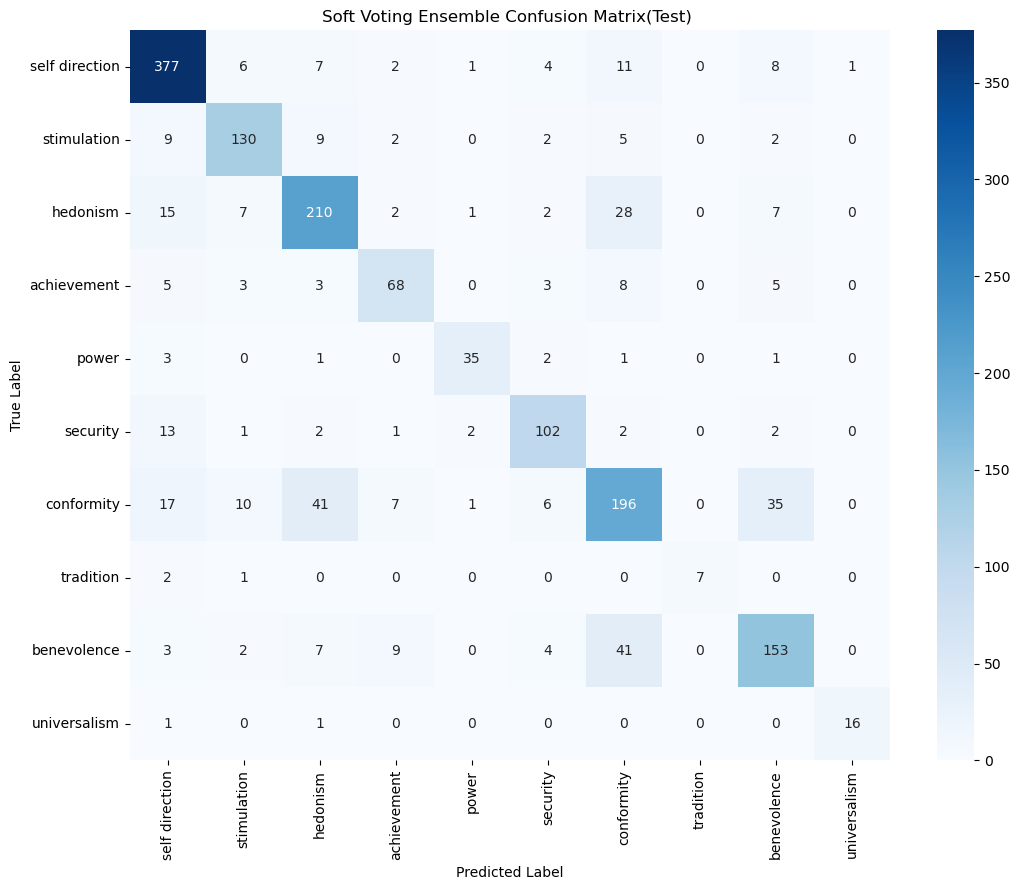

✅ Saved: Soft_Voting_Ensemble_Confusion_Matrix(Test)__CM.png

🎯 FINAL SUMMARY

Automatic class remapping:
CNN_REMAP   = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
BIGRU_REMAP = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Individual models:
CNN          | Acc=0.6589 | Macro-F1=0.6173 | Weighted-F1=0.6539
BiGRU        | Acc=0.6469 | Macro-F1=0.6538 | Weighted-F1=0.6405
DistilBERT   | Acc=0.7540 | Macro-F1=0.7634 | Weighted-F1=0.7533
BERT         | Acc=0.7582 | Macro-F1=0.7716 | Weighted-F1=0.7575

Selected final soft-voting ensemble:
BERT + DistilBERT + BiGRU + CNN               | Acc=0.7744 | Macro-F1=0.7934 | Weighted-F1=0.7728

Gain over BERT baseline:
Accuracy gain   : +0.0162 (+1.62 pp)
Macro-F1 gain   : +0.0218 (+2.18 pp)
Weighted-F1 gain: +0.0152 (+1.52 pp)

Saved files:
  - automatic_class_remapping.csv
  - final_soft_voting_ablation_with_remapping.csv
  - final_classwise_cnn_weights.csv
  - overall_performance_vs_bert_with_remapping.csv
  - per_class_f1_gain_vs_bert_with_remapping.csv
  - final_predict

In [1]:
# FINAL SOFT VOTING ENSEMBLE SCRIPT With Automatic Class Remapping
# CNN + BiGRU + DistilBERT + BERT

#
# Requirements:
#   - newextendeddataset.csv
#   - final_cnn_model.h5
#   - final_cnn_tokenizer.pkl
#   - final_bigru_model.h5
#   - final_bigru_tokenizer.pkl
#   - ./distilbert_best_cv
#   - ./bert_best_cv
#

import os

# Force TensorFlow to CPU before importing tensorflow/keras
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import re
import json
import pickle
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

import nltk
import torch
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    BertTokenizerFast,
    BertForSequenceClassification
)

warnings.filterwarnings("ignore")

# 1. CONFIGURATION

SEED = 42
DATA_PATH = "newextendeddataset.csv"

CNN_MODEL_PATH = "./final_cnn_model.h5"
CNN_TOKENIZER_PATH = "./final_cnn_tokenizer.pkl"

BIGRU_MODEL_PATH = "./final_bigru_model.h5"
BIGRU_TOKENIZER_PATH = "./final_bigru_tokenizer.pkl"

DISTILBERT_PATH = "./distilbert_best_cv"
BERT_PATH = "./bert_best_cv"

MAX_LEN_RNN = 100
MAX_LEN_BERT = 128

BATCH_SIZE_RNN = 16
BATCH_SIZE_BERT = 8

# Keep final test set frozen at 15%
TEST_SIZE = 0.15

# Calibration set is used only to infer automatic class remapping.
CALIB_SIZE_FROM_TRAIN = 0.15

AUTOMATIC_REMAP = True

np.random.seed(SEED)
torch.manual_seed(SEED)

# Canonical class order
y_dict = {
    "self direction": 0,
    "stimulation": 1,
    "hedonism": 2,
    "achievement": 3,
    "power": 4,
    "security": 5,
    "conformity": 6,
    "tradition": 7,
    "benevolence": 8,
    "universalism": 9
}

class_labels = list(y_dict.keys())
n_classes = len(class_labels)

print("✅ Canonical class order (0→9):")
for i, name in enumerate(class_labels):
    print(f"{i}: {name}")

# 2. NLTK SETUP

nltk.download("punkt", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

tag_map = defaultdict(lambda: "n")
tag_map["J"] = "a"
tag_map["V"] = "v"
tag_map["R"] = "r"

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


def clean_text_for_rnn(text):
    """
    Exact preprocessing for CNN/BiGRU models.
    """
    if not isinstance(text, str):
        return ""

    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = text.lower()
    text = re.sub(r"[/(){}\[\]\<\>\|@,;]", " ", text)
    text = re.sub(r"[^a-z #+_]", "", text)

    tokens = word_tokenize(text)

    final_words = []
    for word, pos in pos_tag(tokens):
        if word not in stop_words and word.isalpha():
            pos_tag_simple = tag_map[pos[0]] if pos else "n"
            lemma = lemmatizer.lemmatize(word, pos=pos_tag_simple)
            final_words.append(lemma)

    return " ".join(final_words)


# 3. LOAD DATA

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

df["category_clean"] = df["category"].str.strip().str.lower()
df["label_id"] = df["category_clean"].map(y_dict)

df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

texts = df["Base_Reviews"].values
y_all = df["label_id"].values

# Final train/test split
X_train_pool_raw, X_test_raw, y_train_pool, y_test_true = train_test_split(
    texts,
    y_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all
)

# Calibration split for automatic class remapping
X_train_unused_raw, X_calib_raw, y_train_unused, y_calib_true = train_test_split(
    X_train_pool_raw,
    y_train_pool,
    test_size=CALIB_SIZE_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_pool
)

print("\n✅ Final Splits:")
print(f"   Train pool : {len(X_train_pool_raw)} samples")
print(f"   Calibration: {len(X_calib_raw)} samples")
print(f"   Test       : {len(X_test_raw)} samples")

# 4. DEVICE SETUP

try:
    tf.config.set_visible_devices([], "GPU")
    print("✅ TensorFlow will use CPU only")
except Exception as e:
    print(f"⚠️ TensorFlow GPU disabling warning: {e}")

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using PyTorch device: {device}")

# 5. LOAD MODELS

print("\nLoading models...")

try:
    cnn_model = load_model(CNN_MODEL_PATH, compile=False)
    with open(CNN_TOKENIZER_PATH, "rb") as f:
        cnn_tokenizer = pickle.load(f)
    print("✅ CNN loaded")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load CNN: {e}")

try:
    bigru_model = load_model(BIGRU_MODEL_PATH, compile=False)
    with open(BIGRU_TOKENIZER_PATH, "rb") as f:
        bigru_tokenizer = pickle.load(f)
    print("✅ BiGRU loaded")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load BiGRU: {e}")

try:
    distilbert_model = DistilBertForSequenceClassification.from_pretrained(DISTILBERT_PATH)
    distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_PATH)
    distilbert_model.to(device)
    distilbert_model.eval()
    print("✅ DistilBERT loaded")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load DistilBERT: {e}")

try:
    bert_model = BertForSequenceClassification.from_pretrained(BERT_PATH)
    bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_PATH)
    bert_model.to(device)
    bert_model.eval()
    print("✅ BERT loaded")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load BERT: {e}")

# 6. PREDICTION FUNCTIONS

def batched_predict(predict_func, texts, batch_size):
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        probs = predict_func(batch)
        all_probs.append(probs)

    return np.vstack(all_probs)


def get_cnn_raw_proba(texts):
    cleaned = [clean_text_for_rnn(t) for t in texts]
    seqs = cnn_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seqs, maxlen=MAX_LEN_RNN, padding="post")
    probs = cnn_model.predict(padded, verbose=0)

    if probs.shape[1] != n_classes:
        raise ValueError(f"CNN output classes = {probs.shape[1]}, expected {n_classes}")

    return probs


def get_bigru_raw_proba(texts):
    cleaned = [clean_text_for_rnn(t) for t in texts]
    seqs = bigru_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seqs, maxlen=MAX_LEN_RNN, padding="post")
    probs = bigru_model.predict(padded, verbose=0)

    if probs.shape[1] != n_classes:
        raise ValueError(f"BiGRU output classes = {probs.shape[1]}, expected {n_classes}")

    return probs


def get_distilbert_proba(texts):
    inputs = distilbert_tokenizer(
        [str(t) for t in texts],
        padding=True,
        truncation=True,
        max_length=MAX_LEN_BERT,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = distilbert_model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

    if probs.shape[1] != n_classes:
        raise ValueError(f"DistilBERT output classes = {probs.shape[1]}, expected {n_classes}")

    return probs


def get_bert_proba(texts):
    inputs = bert_tokenizer(
        [str(t) for t in texts],
        padding=True,
        truncation=True,
        max_length=MAX_LEN_BERT,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = bert_model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

    if probs.shape[1] != n_classes:
        raise ValueError(f"BERT output classes = {probs.shape[1]}, expected {n_classes}")

    return probs


# 7. AUTOMATIC CLASS REMAPPING

def infer_remapping(raw_predict_func, texts, y_true, model_name, batch_size):
    """
    Automatic class remapping by mode matching.

    For each raw output class j, find the true class that appears most often
    among samples predicted as j on the calibration set.
    """

    print("\n" + "-" * 70)
    print(f"🔁 Inferring automatic class remapping for {model_name}")
    print("-" * 70)

    probs = batched_predict(raw_predict_func, texts, batch_size=batch_size)
    y_pred_raw = np.argmax(probs, axis=1)

    remap = [0] * n_classes
    mapping_rows = []

    for raw_class in range(n_classes):
        mask = y_pred_raw == raw_class

        if np.any(mask):
            true_labels = y_true[mask]
            canonical_class = int(np.bincount(true_labels, minlength=n_classes).argmax())
            count = int(mask.sum())
            confidence = float(np.mean(true_labels == canonical_class))

            remap[raw_class] = canonical_class

            print(
                f"{model_name} output[{raw_class:2d}] "
                f"→ canonical[{canonical_class:2d}] "
                f"({class_labels[canonical_class]:15s}) | "
                f"freq={count:4d} | mode_conf={confidence:.4f}"
            )

            mapping_rows.append({
                "model": model_name,
                "raw_class_id": raw_class,
                "mapped_class_id": canonical_class,
                "mapped_class_name": class_labels[canonical_class],
                "frequency": count,
                "mode_confidence": confidence
            })

        else:
            remap[raw_class] = raw_class

            print(
                f"{model_name} output[{raw_class:2d}] "
                f"→ no calibration predictions; fallback to identity {raw_class}"
            )

            mapping_rows.append({
                "model": model_name,
                "raw_class_id": raw_class,
                "mapped_class_id": raw_class,
                "mapped_class_name": class_labels[raw_class],
                "frequency": 0,
                "mode_confidence": 0.0
            })

    return remap, mapping_rows


def remap_probs(probs, mapping):
    """
    Remap probability columns into the canonical class order.
    """
    new_probs = np.zeros_like(probs)

    for old_idx, new_idx in enumerate(mapping):
        new_probs[:, new_idx] += probs[:, old_idx]

    return new_probs


if AUTOMATIC_REMAP:
    CNN_REMAP, cnn_mapping_rows = infer_remapping(
        get_cnn_raw_proba,
        X_calib_raw,
        y_calib_true,
        "CNN",
        BATCH_SIZE_RNN
    )

    BIGRU_REMAP, bigru_mapping_rows = infer_remapping(
        get_bigru_raw_proba,
        X_calib_raw,
        y_calib_true,
        "BiGRU",
        BATCH_SIZE_RNN
    )
else:
    CNN_REMAP = list(range(n_classes))
    BIGRU_REMAP = list(range(n_classes))
    cnn_mapping_rows = []
    bigru_mapping_rows = []

print("\n✅ Final automatic remapping:")
print(f"CNN_REMAP   = {CNN_REMAP}")
print(f"BIGRU_REMAP = {BIGRU_REMAP}")

mapping_df = pd.DataFrame(cnn_mapping_rows + bigru_mapping_rows)
mapping_df.to_csv("automatic_class_remapping.csv", index=False)
print("✅ Saved: automatic_class_remapping.csv")


def get_cnn_proba(texts):
    raw = get_cnn_raw_proba(texts)
    return remap_probs(raw, CNN_REMAP)


def get_bigru_proba(texts):
    raw = get_bigru_raw_proba(texts)
    return remap_probs(raw, BIGRU_REMAP)

# 8. HELPER FUNCTIONS

def normalize_rows(probs):
    row_sum = probs.sum(axis=1, keepdims=True)
    return probs / np.maximum(row_sum, 1e-12)


def weighted_sum(prob_dict, weights):
    total = sum(weights.values())

    if total <= 0:
        raise ValueError("Weight sum must be positive.")

    probs = np.zeros_like(next(iter(prob_dict.values())))

    for model_name, w in weights.items():
        probs += (w / total) * prob_dict[model_name]

    return normalize_rows(probs)


def classwise_cnn_fusion(prob_dict):
    """
    Final selected fusion.

        BERT + DistilBERT + BiGRU form the base ensemble.
    """

    base_weights = {
        "BERT": 0.39,
        "DistilBERT": 0.36,
        "BiGRU": 0.25
    }

    base_probs = weighted_sum(prob_dict, base_weights)

    # Canonical class order:
    # 0 self direction
    # 1 stimulation
    # 2 hedonism
    # 3 achievement
    # 4 power
    # 5 security
    # 6 conformity
    # 7 tradition
    # 8 benevolence
    # 9 universalism

    cnn_class_weights = np.array([
        0.10,  # self direction
        0.02,  # stimulation
        0.10,  # hedonism
        0.05,  # achievement
        0.02,  # power
        0.03,  # security
        0.02,  # conformity
        0.03,  # tradition
        0.08,  # benevolence
        0.02   # universalism
    ], dtype=np.float64)

    cnn_class_adjusted = prob_dict["CNN"] * cnn_class_weights.reshape(1, -1)

    final_probs = normalize_rows(base_probs + cnn_class_adjusted)

    return final_probs, base_weights, cnn_class_weights


def evaluate_probs(name, probs, y_true):
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    weighted_f1 = f1_score(y_true, preds, average="weighted")

    print(
        f"{name:60s} | "
        f"Acc={acc:.4f} | "
        f"Macro-F1={macro_f1:.4f} | "
        f"Weighted-F1={weighted_f1:.4f}"
    )

    return {
        "name": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "preds": preds,
        "probs": probs
    }


def evaluate_direct_preds(name, preds, y_true):
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    weighted_f1 = f1_score(y_true, preds, average="weighted")

    print(
        f"{name:60s} | "
        f"Acc={acc:.4f} | "
        f"Macro-F1={macro_f1:.4f} | "
        f"Weighted-F1={weighted_f1:.4f}"
    )

    return {
        "name": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "preds": preds
    }


def per_class_f1_dict(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(n_classes)),
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )

    return {label: report[label]["f1-score"] for label in class_labels}


def format_pct(x):
    return round(float(x) * 100.0, 2)


def format_delta_pp(x):
    return round(float(x) * 100.0, 2)


def save_confusion_matrix(prefix, y_true, y_pred):
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

        plt.figure(figsize=(11, 9))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(prefix)
        plt.tight_layout()

        png_name = f"{prefix.replace(' ', '_').replace('+', 'plus').replace('/', '_')}_CM.png"
        plt.savefig(png_name, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"✅ Saved: {png_name}")

    except Exception as e:
        print(f"⚠️ Confusion matrix skipped: {e}")

# 9. COMPUTE MODEL PROBABILITIES ON FINAL TEST SET

print("\n" + "=" * 90)
print("🔍 COMPUTING MODEL PROBABILITIES ON FINAL TEST SET")
print("=" * 90)

model_specs = {
    "CNN": (get_cnn_proba, BATCH_SIZE_RNN),
    "BiGRU": (get_bigru_proba, BATCH_SIZE_RNN),
    "DistilBERT": (get_distilbert_proba, BATCH_SIZE_BERT),
    "BERT": (get_bert_proba, BATCH_SIZE_BERT)
}

model_probs = {}
single_results = {}

for name, (prob_func, batch_size) in model_specs.items():
    print(f"→ Evaluating {name}...")

    probs = batched_predict(prob_func, X_test_raw, batch_size=batch_size)
    probs = normalize_rows(probs)

    preds = np.argmax(probs, axis=1)

    model_probs[name] = probs
    single_results[name] = evaluate_direct_preds(f"{name} only", preds, y_test_true)

individual_accs = {name: result["accuracy"] for name, result in single_results.items()}
individual_macro_f1 = {name: result["macro_f1"] for name, result in single_results.items()}

print("\n✅ Individual accuracy weights:")
for name, acc in individual_accs.items():
    print(f"{name:12s}: {acc:.4f}")

# 10. SOFT-VOTING ABLATION STUDY

print("\n" + "=" * 90)
print("🧩SOFT-VOTING ABLATION STUDY")
print("=" * 90)

ensemble_sets = {
    "BERT + DistilBERT": ["BERT", "DistilBERT"],
    "BERT + DistilBERT + CNN": ["BERT", "DistilBERT", "CNN"],
    "BERT + BiGRU": ["BERT", "BiGRU"],
    "DistilBERT + BiGRU": ["DistilBERT", "BiGRU"],
    "BERT + CNN": ["BERT", "CNN"],
    "BERT + CNN + BiGRU": ["BERT", "CNN", "BiGRU"],
    "CNN + BiGRU": ["CNN", "BiGRU"]
}

ensemble_results = {}
ablation_rows = []

for ens_name, model_names in ensemble_sets.items():

    # Accuracy-weighted soft voting
    weights = {m: individual_accs[m] for m in model_names}
    probs = weighted_sum(model_probs, weights)

    result = evaluate_probs(
        ens_name,
        probs,
        y_test_true
    )

    ensemble_results[ens_name] = result

    ablation_rows.append({
        "Ensemble": ens_name,
        "Fusion": "soft voting",
        "Models": " + ".join(model_names),
        "Accuracy": result["accuracy"],
        "Macro_F1": result["macro_f1"],
        "Weighted_F1": result["weighted_f1"],
        "Accuracy_%": format_pct(result["accuracy"]),
        "Macro_F1_%": format_pct(result["macro_f1"]),
        "Weighted_F1_%": format_pct(result["weighted_f1"]),
        "Weights": weights
    })


# 11. FINAL SOFT-VOTING ENSEMBLE

# Final selected class-wise CNN soft-voting ensemble
classwise_probs, base_weights, cnn_class_weights = classwise_cnn_fusion(model_probs)

classwise_result = evaluate_probs(
    "FINAL: BERT + DistilBERT + BiGRU + CNN",
    classwise_probs,
    y_test_true
)

ensemble_results["FINAL Soft Voting Ensemble Fusion"] = classwise_result

ablation_rows.append({
    "Ensemble": "BERT + DistilBERT + BiGRU + CNN",
    "Fusion": "Soft Voting ",
    "Models": "BERT + DistilBERT + BiGRU + CNN",
    "Accuracy": classwise_result["accuracy"],
    "Macro_F1": classwise_result["macro_f1"],
    "Weighted_F1": classwise_result["weighted_f1"],
    "Accuracy_%": format_pct(classwise_result["accuracy"]),
    "Macro_F1_%": format_pct(classwise_result["macro_f1"]),
    "Weighted_F1_%": format_pct(classwise_result["weighted_f1"]),
    "Weights": {
        "base_weights": base_weights,
        "cnn_class_weights": cnn_class_weights.tolist()
    }
})

# Sort table by Accuracy and Macro-F1
ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df.sort_values(
    by=["Accuracy", "Macro_F1"],
    ascending=False
)

print("\nAblation table:")
print(
    ablation_df[
        ["Ensemble", "Fusion", "Accuracy_%", "Macro_F1_%", "Weighted_F1_%"]
    ].to_string(index=False)
)

ablation_df.to_csv("final_ablation.csv", index=False)
print("\n✅ Saved: final_ablation.csv")


# 12. FINAL SELECTED MODEL

final_ensemble_name = "BERT + DistilBERT + BiGRU + CNN"
final_result = classwise_result
y_pred_final = final_result["preds"]
final_probs = final_result["probs"]

bert_result = single_results["BERT"]
y_pred_bert = bert_result["preds"]

print("\n" + "=" * 90)
print("FINAL SELECTED MODEL")
print("=" * 90)

print(f"Selected model: {final_ensemble_name}")
print(f"Fusion        : soft voting with automatic class remapping")
print(f"Accuracy      : {final_result['accuracy']:.4f} ({format_pct(final_result['accuracy'])}%)")
print(f"Macro-F1      : {final_result['macro_f1']:.4f} ({format_pct(final_result['macro_f1'])}%)")
print(f"Weighted-F1   : {final_result['weighted_f1']:.4f} ({format_pct(final_result['weighted_f1'])}%)")

print("\nBase soft-voting weights:")
for k, v in base_weights.items():
    print(f"  {k:12s}: {v:.4f}")

print("\nClass-wise CNN weights:")
for i, label in enumerate(class_labels):
    print(f"  {i:2d} {label:15s}: {cnn_class_weights[i]:.4f}")

pd.DataFrame({
    "class_id": list(range(n_classes)),
    "class_name": class_labels,
    "cnn_class_weight": cnn_class_weights
}).to_csv("final_classwise_cnn_weights.csv", index=False)

print("\n✅ Saved: final_classwise_cnn_weights.csv")


# 13. OVERALL PERFORMANCE VS BERT BASELINE

print("\n" + "=" * 90)
print("OVERALL PERFORMANCE VS BEST SINGLE BERT")
print("=" * 90)

overall_rows = []

overall_rows.append({
    "Model": "BERT (best single)",
    "Fusion": "Single model",
    "Accuracy": format_pct(bert_result["accuracy"]),
    "Macro F1": format_pct(bert_result["macro_f1"]),
    "Weighted F1": format_pct(bert_result["weighted_f1"]),
    "Δ vs. BERT Macro-F1 (pp)": "—"
})

for ens_name in ensemble_sets.keys():
    r = ensemble_results[ens_name]

    overall_rows.append({
        "Model": ens_name,
        "Fusion": "soft voting",
        "Accuracy": format_pct(r["accuracy"]),
        "Macro F1": format_pct(r["macro_f1"]),
        "Weighted F1": format_pct(r["weighted_f1"]),
        "Δ vs. BERT Macro-F1 (pp)": format_delta_pp(
            r["macro_f1"] - bert_result["macro_f1"]
        )
    })

overall_rows.append({
    "Model": "Final BERT + DistilBERT + CNN + BiGRU",
    "Fusion": "soft voting",
    "Accuracy": format_pct(final_result["accuracy"]),
    "Macro F1": format_pct(final_result["macro_f1"]),
    "Weighted F1": format_pct(final_result["weighted_f1"]),
    "Δ vs. BERT Macro-F1 (pp)": format_delta_pp(
        final_result["macro_f1"] - bert_result["macro_f1"]
    )
})

overall_comparison_df = pd.DataFrame(overall_rows)

print(overall_comparison_df.to_string(index=False))

overall_comparison_df.to_csv(
    "overall_performance_vs_bert_with_remapping.csv",
    index=False
)

print("\n✅ Saved: overall_performance_vs_bert_with_remapping.csv")

# 14. PER-CLASS F1 GAIN VS BERT BASELINE

print("\n" + "=" * 90)
print("PER-CLASS F1 GAIN VS BERT BASELINE")
print("=" * 90)

bert_class_f1 = per_class_f1_dict(y_test_true, y_pred_bert)
soft_class_f1 = per_class_f1_dict(y_test_true, y_pred_final)

support_counts = pd.Series(y_test_true).value_counts().sort_index().to_dict()

per_class_rows = []

for class_id, class_name in enumerate(class_labels):
    support = int(support_counts.get(class_id, 0))

    bert_f1 = bert_class_f1[class_name]
    soft_f1 = soft_class_f1[class_name]
    delta_f1 = soft_f1 - bert_f1

    per_class_rows.append({
        "Class": class_name,
        "Support": support,
        "BERT F1": format_pct(bert_f1),
        "Final Soft Vote F1": format_pct(soft_f1),
        "Δ F1 (pp) Soft - BERT": format_delta_pp(delta_f1)
    })

per_class_rows.append({
    "Class": "Macro Avg",
    "Support": int(len(y_test_true)),
    "BERT F1": format_pct(bert_result["macro_f1"]),
    "Final Soft Vote F1": format_pct(final_result["macro_f1"]),
    "Δ F1 (pp) Soft - BERT": format_delta_pp(
        final_result["macro_f1"] - bert_result["macro_f1"]
    )
})

per_class_rows.append({
    "Class": "Weighted Avg",
    "Support": int(len(y_test_true)),
    "BERT F1": format_pct(bert_result["weighted_f1"]),
    "Final Soft Vote F1": format_pct(final_result["weighted_f1"]),
    "Δ F1 (pp) Soft - BERT": format_delta_pp(
        final_result["weighted_f1"] - bert_result["weighted_f1"]
    )
})

per_class_gain_df = pd.DataFrame(per_class_rows)

print(per_class_gain_df.to_string(index=False))

per_class_gain_df.to_csv(
    "per_class_f1_gain_vs_bert_with_remapping.csv",
    index=False
)

print("\n✅ Saved: per_class_f1_gain_vs_bert_with_remapping.csv")

# 15. FINAL CLASSIFICATION REPORTS

print("\n" + "=" * 90)
print("📊 CLASSIFICATION REPORT: FINAL SOFT VOTING ENSEMBLE")
print("=" * 90)

print(
    classification_report(
        y_test_true,
        y_pred_final,
        labels=list(range(n_classes)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

print("\n" + "=" * 90)
print("📊 CLASSIFICATION REPORT: BERT BASELINE")
print("=" * 90)

print(
    classification_report(
        y_test_true,
        y_pred_bert,
        labels=list(range(n_classes)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

# 16. SAVE FINAL PREDICTIONS

prediction_df = pd.DataFrame({
    "text": X_test_raw,
    "true_id": y_test_true,
    "true_label": [class_labels[i] for i in y_test_true],
    "pred_bert_id": y_pred_bert,
    "pred_bert_label": [class_labels[i] for i in y_pred_bert],
    "pred_final_soft_vote_id": y_pred_final,
    "pred_final_soft_vote_label": [class_labels[i] for i in y_pred_final],
    "bert_correct": y_pred_bert == y_test_true,
    "final_soft_vote_correct": y_pred_final == y_test_true
})

prediction_df.to_csv(
    "final_predictions_vs_bert_with_remapping.csv",
    index=False
)

print("\n✅ Saved: final_predictions_vs_bert_with_remapping.csv")


# 17. CONFUSION MATRIX

save_confusion_matrix(
    "Soft Voting Ensemble Confusion Matrix(Test) ",
    y_test_true,
    y_pred_final
)


# 18. FINAL SUMMARY

print("\n" + "=" * 90)
print("🎯 FINAL SUMMARY")
print("=" * 90)

print("\nAutomatic class remapping:")
print(f"CNN_REMAP   = {CNN_REMAP}")
print(f"BIGRU_REMAP = {BIGRU_REMAP}")

print("\nIndividual models:")
for name in ["CNN", "BiGRU", "DistilBERT", "BERT"]:
    r = single_results[name]
    print(
        f"{name:12s} | "
        f"Acc={r['accuracy']:.4f} | "
        f"Macro-F1={r['macro_f1']:.4f} | "
        f"Weighted-F1={r['weighted_f1']:.4f}"
    )

print("\nSelected final soft-voting ensemble:")
print(
    f"{final_ensemble_name:45s} | "
    f"Acc={final_result['accuracy']:.4f} | "
    f"Macro-F1={final_result['macro_f1']:.4f} | "
    f"Weighted-F1={final_result['weighted_f1']:.4f}"
)

print("\nGain over BERT baseline:")
print(
    f"Accuracy gain   : "
    f"{final_result['accuracy'] - bert_result['accuracy']:+.4f} "
    f"({format_delta_pp(final_result['accuracy'] - bert_result['accuracy']):+.2f} pp)"
)

print(
    f"Macro-F1 gain   : "
    f"{final_result['macro_f1'] - bert_result['macro_f1']:+.4f} "
    f"({format_delta_pp(final_result['macro_f1'] - bert_result['macro_f1']):+.2f} pp)"
)

print(
    f"Weighted-F1 gain: "
    f"{final_result['weighted_f1'] - bert_result['weighted_f1']:+.4f} "
    f"({format_delta_pp(final_result['weighted_f1'] - bert_result['weighted_f1']):+.2f} pp)"
)

print("\nSaved files:")
print("  - automatic_class_remapping.csv")
print("  - final_soft_voting_ablation_with_remapping.csv")
print("  - final_classwise_cnn_weights.csv")
print("  - overall_performance_vs_bert_with_remapping.csv")
print("  - per_class_f1_gain_vs_bert_with_remapping.csv")
print("  - final_predictions_vs_bert_with_remapping.csv")
print("  - Final_Soft_Voting_Ensemble_With_Automatic_Remapping_CM.png")

print("\n🎉 Final soft-voting ensemble with automatic class remapping complete.")